<a href="https://colab.research.google.com/github/siddhantsawhney327/6thSem-ML-Lab/blob/main/1BM23CS327_Lab_8_AdaBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of dataset:
   age  fnlwgt  education_num  capital_gain  capital_loss  hours_per_week  \
0   39   77516             13          2174             0              40   
1   50   83311             13             0             0              13   
2   38  215646              9             0             0              40   
3   53  234721              7             0             0              40   
4   28  338409             13             0             0              40   

   income_level  
0             0  
1             0  
2             0  
3             0  
4             0  

Dataset Shape:
(48842, 7)

Column Names:
Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week', 'income_level'],
      dtype='object')

Missing values in each column:
age               0
fnlwgt            0
education_num     0
capital_gain      0
capital_loss      0
hours_per_week    0
income_level      0
dtype: int64

Dataset Shape after removing missing va

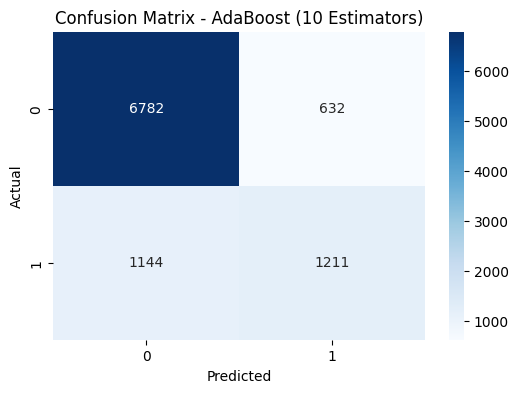


=== TUNING n_estimators ===
Number of Estimators = 5, Accuracy = 0.8100112601085065
Number of Estimators = 10, Accuracy = 0.8182004299314157
Number of Estimators = 20, Accuracy = 0.8244446719213839
Number of Estimators = 50, Accuracy = 0.8327362063670796
Number of Estimators = 100, Accuracy = 0.8328385709898659
Number of Estimators = 150, Accuracy = 0.8329409356126523
Number of Estimators = 200, Accuracy = 0.8332480294810114

=== BEST MODEL ===
Best Accuracy Score: 0.8332480294810114
Best Number of Estimators: 200

Confusion Matrix for Best Model:
 [[7028  386]
 [1243 1112]]

Classification Report for Best Model:
               precision    recall  f1-score   support

           0       0.85      0.95      0.90      7414
           1       0.74      0.47      0.58      2355

    accuracy                           0.83      9769
   macro avg       0.80      0.71      0.74      9769
weighted avg       0.82      0.83      0.82      9769



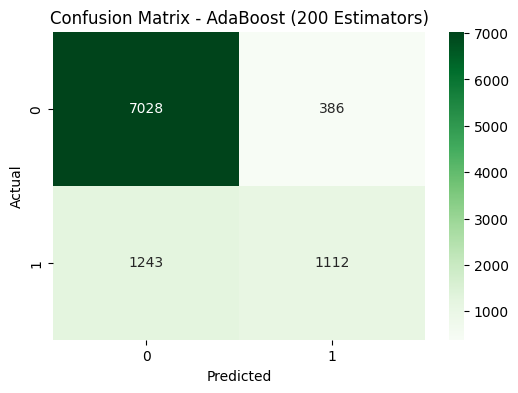

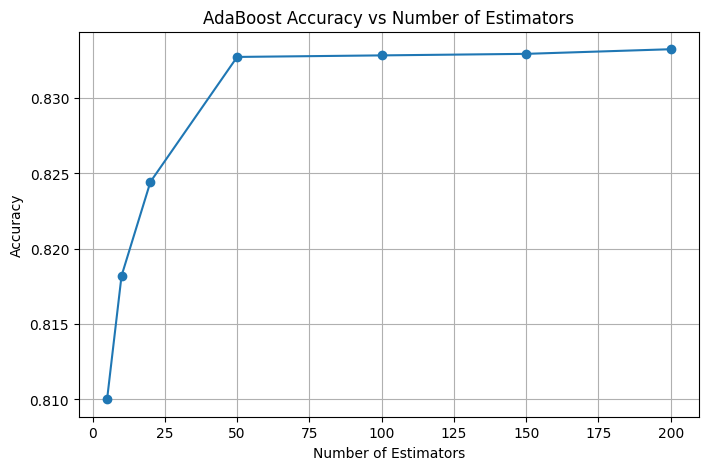

In [1]:
# ==========================================
# LAB-8: ADABOOST CLASSIFIER - INCOME DATASET
# ==========================================

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Load dataset
df = pd.read_csv("income.csv")

# Step 3: Display dataset information
print("First 5 rows of dataset:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing values in each column:")
print(df.isnull().sum())

# Step 4: Handle missing values (if any)
# Replace '?' with NaN and drop missing rows
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

print("\nDataset Shape after removing missing values:")
print(df.shape)

# Step 5: Encode categorical columns
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Step 6: Separate features and target
# Assuming last column is the target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

# Step 7: Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# DEFAULT MODEL (n_estimators = 10)
# ==========================================
ada_default = AdaBoostClassifier(n_estimators=10, random_state=42)
ada_default.fit(X_train, y_train)

y_pred_default = ada_default.predict(X_test)

acc_default = accuracy_score(y_test, y_pred_default)
cm_default = confusion_matrix(y_test, y_pred_default)

print("\n=== ADABOOST WITH DEFAULT n_estimators=10 ===")
print("Accuracy:", acc_default)
print("Confusion Matrix:\n", cm_default)
print("\nClassification Report:\n", classification_report(y_test, y_pred_default))

# Plot confusion matrix for default model
plt.figure(figsize=(6,4))
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - AdaBoost (10 Estimators)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================
# FINE TUNING n_estimators
# ==========================================
estimator_values = [5, 10, 20, 50, 100, 150, 200]
scores = []

print("\n=== TUNING n_estimators ===")
for n in estimator_values:
    ada = AdaBoostClassifier(n_estimators=n, random_state=42)
    ada.fit(X_train, y_train)
    y_pred = ada.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    scores.append(acc)
    print(f"Number of Estimators = {n}, Accuracy = {acc}")

# Step 8: Find best score and best estimator count
best_score = max(scores)
best_estimators = estimator_values[scores.index(best_score)]

print("\n=== BEST MODEL ===")
print("Best Accuracy Score:", best_score)
print("Best Number of Estimators:", best_estimators)

# Step 9: Train best model
best_ada = AdaBoostClassifier(n_estimators=best_estimators, random_state=42)
best_ada.fit(X_train, y_train)
y_pred_best = best_ada.predict(X_test)

best_cm = confusion_matrix(y_test, y_pred_best)

print("\nConfusion Matrix for Best Model:\n", best_cm)
print("\nClassification Report for Best Model:\n", classification_report(y_test, y_pred_best))

# Plot best confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Greens')
plt.title(f"Confusion Matrix - AdaBoost ({best_estimators} Estimators)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 10: Plot Accuracy vs Number of Estimators
plt.figure(figsize=(8,5))
plt.plot(estimator_values, scores, marker='o')
plt.title("AdaBoost Accuracy vs Number of Estimators")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()